### DATASET SELECCIONADO
- Calidad de vida/felicidad, respecto al PIB interno de cada país.

 ### Trabajo en grupo 4

 - Importación de librerias
 - Selección de archivo de análisis de datos desde Github
 - Lectura del documento que se recibe del enlace de Github

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cargamos el dataset directamente desde un link público de confianza (GitHub)
url = "https://raw.githubusercontent.com/VivekAgrawl/World-Happiness-Report-2023/main/whr2023.csv"
df = pd.read_csv(url)

# Representación de las primeras filas del dataset para verificar su estructura
df.head()

,Country name,iso alpha,Regional indicator,Happiness score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,...,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Afghanistan,AFG,South Asia,1.859,0.033,1.923,1.795,7.324,0.341,54.712,...,-0.081,0.847,1.778,0.645,0.000,0.087,0.000,0.093,0.059,0.976
1,Albania,ALB,Central and Eastern Europe,5.277,0.066,5.406,5.148,9.567,0.718,69.150,...,-0.007,0.878,1.778,1.449,0.951,0.480,0.549,0.133,0.037,1.678
2,Algeria,DZA,Middle East and North Africa,5.329,0.062,5.451,5.207,9.300,0.855,66.549,...,-0.117,0.717,1.778,1.353,1.298,0.409,0.252,0.073,0.152,1.791
3,Argentina,ARG,Latin America and Caribbean,6.024,0.063,6.147,5.900,9.959,0.891,67.200,...,-0.089,0.814,1.778,1.590,1.388,0.427,0.587,0.088,0.082,1.861
4,Armenia,ARM,Commonwealth of Independent States,5.342,0.066,5.470,5.213,9.615,0.790,67.789,...,-0.155,0.705,1.778,1.466,1.134,0.443,0.551,0.053,0.160,1.534


- Procesamiento y limpieza de la información del DATASET seleccionado
  - Seleccionamos las columas e imprimos la lista.

In [2]:
# 1. Seleccionamos solo las columnas más importantes para el análisis
cols_to_keep = ['Country name', 'Ladder score', 'Logged GDP per capita', 
                'Social support', 'Healthy life expectancy', 
                'Freedom to make life choices', 'Generosity', 
                'Perceptions of corruption']

print(df.columns.tolist())

['Country name', 'iso alpha', 'Regional indicator', 'Happiness score', 'Standard error of ladder score', 'upperwhisker', 'lowerwhisker', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Ladder score in Dystopia', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']


Procesamiento y limpieza   
   - Pasamos la lista de inglés a español
   - Verificamos los valores nulos y eliminamos los valores nulos.

In [3]:
# 1. Selección con los nombres exactos de TU lista
cols_to_keep = [
    'Country name', 
    'Happiness score', 
    'Logged GDP per capita', 
    'Social support', 
    'Healthy life expectancy', 
    'Freedom to make life choices', 
    'Generosity', 
    'Perceptions of corruption'
]

# Creamos el dataframe limpio
df_clean = df[cols_to_keep].copy()

# 2. Renombrar a español para que el reporte sea profesional
df_clean.columns = [
    'Pais', 
    'Puntaje_Felicidad', 
    'PIB_per_Capita', 
    'Apoyo_Social', 
    'Expectativa_Vida', 
    'Libertad', 
    'Generosidad', 
    'Corrupcion'
]

# 3. Limpieza de datos
print("Valores nulos detectados:\n", df_clean.isnull().sum())
df_clean = df_clean.dropna()

print(f"\n¡Listo! Dataset procesado con {df_clean.shape[0]} países.")
df_clean.head()

Valores nulos detectados:
 Pais                 0
Puntaje_Felicidad    0
PIB_per_Capita       0
Apoyo_Social         0
Expectativa_Vida     1
Libertad             0
Generosidad          0
Corrupcion           0
dtype: int64

¡Listo! Dataset procesado con 136 países.


,Pais,Puntaje_Felicidad,PIB_per_Capita,Apoyo_Social,Expectativa_Vida,Libertad,Generosidad,Corrupcion
0,Afghanistan,1.859,7.324,0.341,54.712,0.382,-0.081,0.847
1,Albania,5.277,9.567,0.718,69.150,0.794,-0.007,0.878
2,Algeria,5.329,9.300,0.855,66.549,0.571,-0.117,0.717
3,Argentina,6.024,9.959,0.891,67.200,0.823,-0.089,0.814
4,Armenia,5.342,9.615,0.790,67.789,0.796,-0.155,0.705


- Análisis exploratorio
   - Se identifica los 10 países más felices y los 10 menos felices.

In [4]:
# Estadísticas descriptivas
stats = df_clean.describe()
print(stats)

# Identificar los 10 países más felices y los 10 menos felices
top_10 = df_clean.nlargest(10, 'Puntaje_Felicidad')
bottom_10 = df_clean.nsmallest(10, 'Puntaje_Felicidad')

print("\nTop 5 Países más felices:\n", top_10[['Pais', 'Puntaje_Felicidad']].head())

       Puntaje_Felicidad  PIB_per_Capita  Apoyo_Social  Expectativa_Vida  \
count         136.000000      136.000000    136.000000        136.000000   
mean            5.544441        9.455191      0.798632         64.967632   
std             1.142841        1.210107      0.129597          5.750390   
min             1.859000        5.527000      0.341000         51.530000   
25%             4.702500        8.587250      0.721000         60.648500   
50%             5.693500        9.574500      0.826500         65.837500   
75%             6.342500       10.540250      0.896000         69.412500   
max             7.804000       11.660000      0.983000         77.280000   

         Libertad  Generosidad  Corrupcion  
count  136.000000   136.000000  136.000000  
mean     0.788081     0.023566    0.724588  
std      0.112498     0.141604    0.177353  
min      0.382000    -0.254000    0.146000  
25%      0.726250    -0.071000    0.666000  
50%      0.801000     0.002000    0.772500  


Visualización de datos
   - Top de los 10 países mas felices.

C:\Users\fausto.almeida\AppData\Local\Temp\ipykernel_56604\288646624.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Puntaje_Felicidad', y='Pais', palette='viridis')


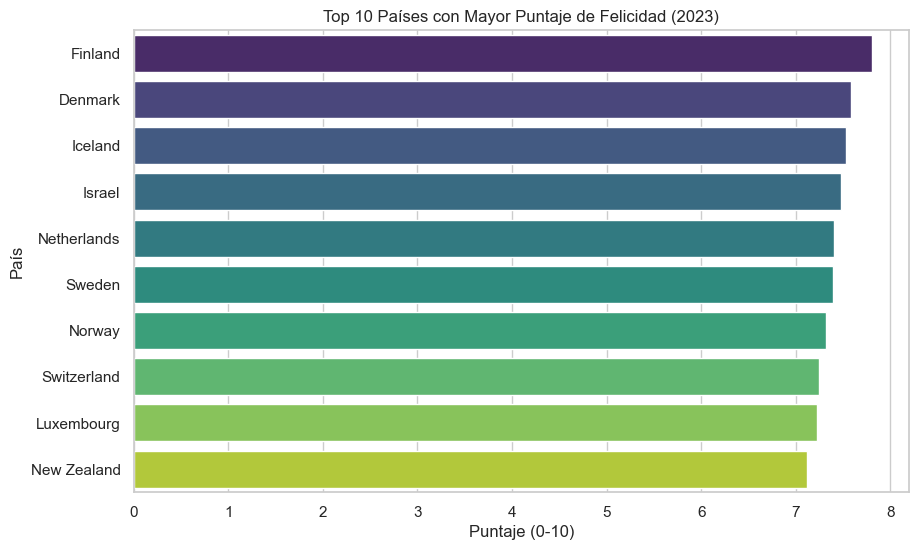

In [5]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_10, x='Puntaje_Felicidad', y='Pais', palette='viridis')
plt.title('Top 10 Países con Mayor Puntaje de Felicidad (2023)')
plt.xlabel('Puntaje (0-10)')
plt.ylabel('País')
plt.show()

 - Mapa de Calor de Correlación (Para ver qué influye más en la felicidad)

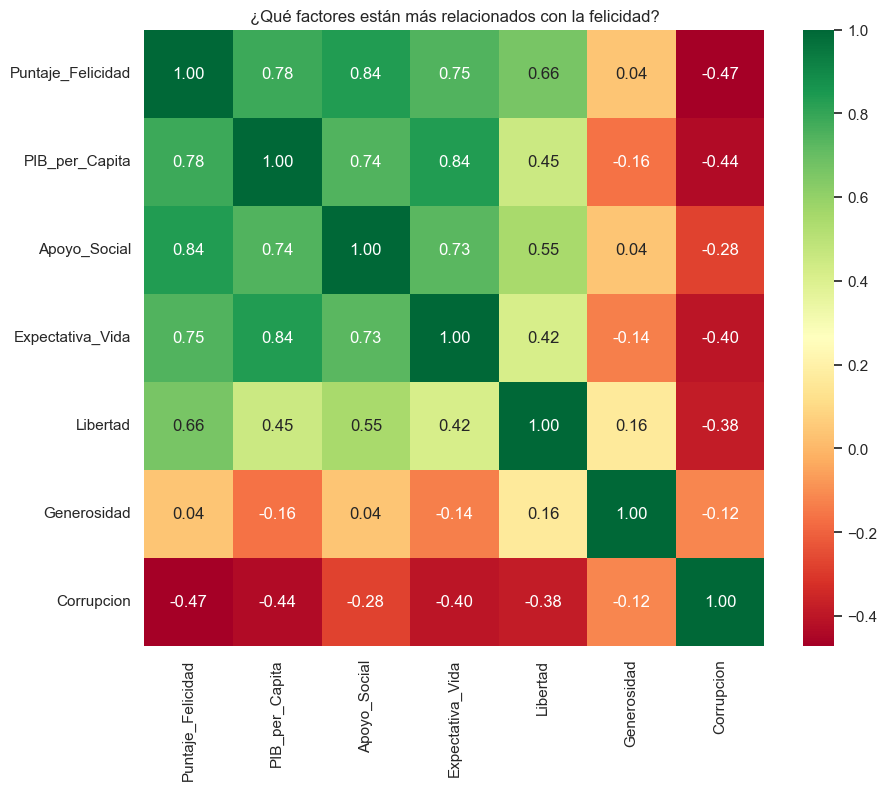

In [6]:
plt.figure(figsize=(10, 8))
correlation = df_clean.drop('Pais', axis=1).corr()
sns.heatmap(correlation, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('¿Qué factores están más relacionados con la felicidad?')
plt.show()

- Mapa Interactivo Global.

In [7]:
fig = px.choropleth(df_clean, 
                    locations="Pais", 
                    locationmode='country names',
                    color="Puntaje_Felicidad", 
                    hover_name="Pais",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title="Distribución Global de la Felicidad")
fig.show()

C:\Users\fausto.almeida\AppData\Local\Temp\ipykernel_56604\2573009775.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df_clean,


- Paises con anomalías, presentan corrupción pero son felices.

Países que desafían la lógica (Alta corrupción pero muy felices):
                         Pais  Puntaje_Felicidad  Corrupcion
5                   Australia              7.095       0.496
6                     Austria              7.097       0.497
9                     Belgium              6.859       0.549
19                     Canada              6.961       0.420
27                 Costa Rica              6.609       0.768
30                    Czechia              6.845       0.859
39                     France              6.661       0.553
43                    Germany              6.892       0.420
51                    Iceland              7.530       0.668
57                     Israel              7.473       0.708
71                  Lithuania              6.763       0.805
103                   Romania              6.589       0.929
111                  Slovenia              6.650       0.771
119  Taiwan Province of China              6.535       0.681
128      United Ara

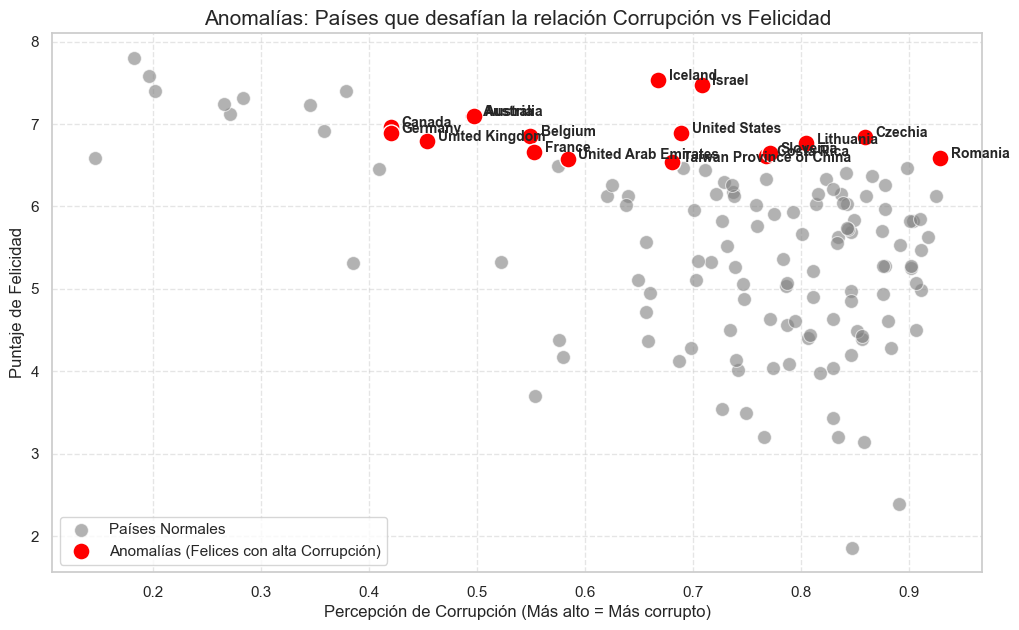

In [8]:
# Detectar anomalías: Países con Corrupción alta (> 0.4) pero Felicidad alta (> 6.5)
anomalias = df_clean[(df_clean['Corrupcion'] > 0.4) & (df_clean['Puntaje_Felicidad'] > 6.5)]

print("Países que desafían la lógica (Alta corrupción pero muy felices):")
print(anomalias[['Pais', 'Puntaje_Felicidad', 'Corrupcion']])

# 2. Crear el gráfico
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clean, x='Corrupcion', y='Puntaje_Felicidad', 
                alpha=0.6, s=100, color='gray', label='Países Normales')

# 3. Resaltar las anomalías en color rojo
sns.scatterplot(data=anomalias, x='Corrupcion', y='Puntaje_Felicidad', 
                color='red', s=150, label='Anomalías (Felices con alta Corrupción)')

# 4. Etiquetar los nombres de los países anómalos para que el profe los vea
for i in range(anomalias.shape[0]):
    plt.text(anomalias.Corrupcion.iloc[i]+0.01, 
             anomalias.Puntaje_Felicidad.iloc[i], 
             anomalias.Pais.iloc[i], 
             fontsize=10, weight='bold')

plt.title('Anomalías: Países que desafían la relación Corrupción vs Felicidad', fontsize=15)
plt.xlabel('Percepción de Corrupción (Más alto = Más corrupto)', fontsize=12)
plt.ylabel('Puntaje de Felicidad', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Machine Learning

- Regresión Lineal para predecir el "Puntaje de Felicidad" basado en el PIB y la Expectativa de Vida.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Seleccionamos variables predictoras (X) y el objetivo (y)
X = df_clean[['PIB_per_Capita', 'Expectativa_Vida', 'Apoyo_Social']]
y = df_clean['Puntaje_Felicidad']

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicción y Evaluación
y_pred = modelo.predict(X_test)
print(f"R2 Score (Precisión): {r2_score(y_test, y_pred):.2f}")

R2 Score (Precisión): 0.74


- Clustering: Agrupación de países por perfiles

 El siguiente script es por Aprendizaje No Supervisado. El modelo encontrará patrones solo.

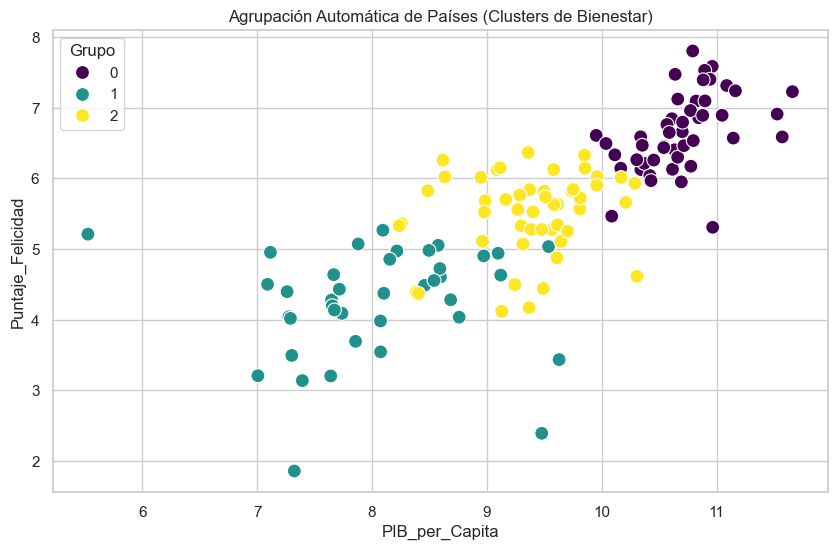

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Preparamos los datos (los modelos de clusters son sensibles a las escalas)
features = ['PIB_per_Capita', 'Expectativa_Vida', 'Apoyo_Social', 'Libertad']
x_clust = df_clean[features]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_clust)

# 2. Creamos 3 grupos (Clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Grupo'] = kmeans.fit_predict(x_scaled)

# 3. Graficamos los grupos
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='PIB_per_Capita', y='Puntaje_Felicidad', 
                hue='Grupo', palette='viridis', s=100)
plt.title('Agrupación Automática de Países (Clusters de Bienestar)')
plt.show()

- Gráfico de "Importancia de Factores"

 Explicación del modelo de machine learning, respecto a la importancia de los factores.

C:\Users\fausto.almeida\AppData\Local\Temp\ipykernel_56604\1438106160.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Factor', data=importancia, palette='magma')


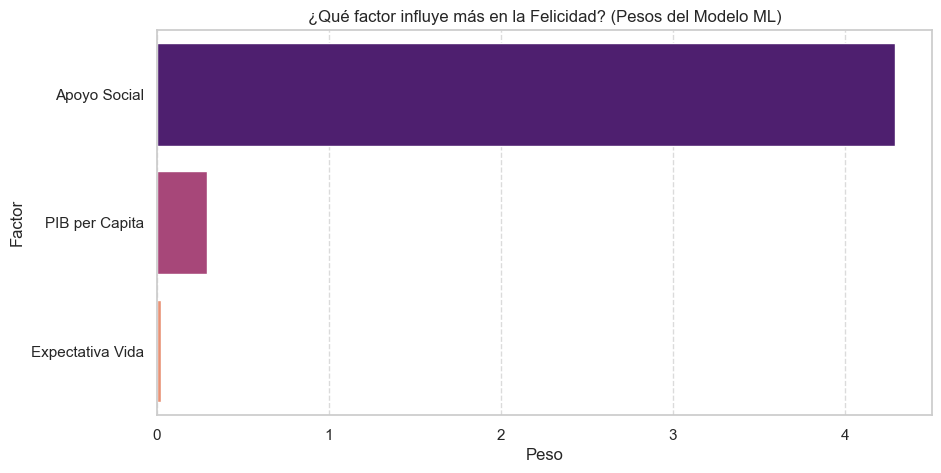

In [11]:
# Extraemos los coeficientes del modelo de regresión que hiciste antes
importancia = pd.DataFrame({
    'Factor': ['PIB per Capita', 'Expectativa Vida', 'Apoyo Social'],
    'Peso': modelo.coef_
})

# Ordenar por importancia
importancia = importancia.sort_values(by='Peso', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Peso', y='Factor', data=importancia, palette='magma')
plt.title('¿Qué factor influye más en la Felicidad? (Pesos del Modelo ML)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()